In [1]:
"""
SpaCross Benchmarking Framework -- BC_HER2+_ST (Juno HPC)
===========================================================
Runs SpaCross on all 8 HER2-positive Breast Cancer ST slices and saves
results in the team-standard parquet format.
 
Dataset citation:
    Andersson A, Larsson L, Stenbeck L et al. Spatial deconvolution of
    HER2-positive breast cancer delineates tumor-associated cell type
    interactions. Nat Commun 12, 6012 (2021).
 
Sample IDs: A1, B1, C1, D1, E1, F1, G2, H1  (note G2, not G1!)
 
Ground-truth annotations (6 tissue types):
    Adipose tissue / Breast glands / Connective tissue /
    Immune infiltrate / In situ cancer / Invasive cancer
"""

'\nSpaCross Benchmarking Framework -- BC_HER2+_ST (Juno HPC)\n===========================================================\nRuns SpaCross on all 8 HER2-positive Breast Cancer ST slices and saves\nresults in the team-standard parquet format.\n \nDataset citation:\n    Andersson A, Larsson L, Stenbeck L et al. Spatial deconvolution of\n    HER2-positive breast cancer delineates tumor-associated cell type\n    interactions. Nat Commun 12, 6012 (2021).\n \nSample IDs: A1, B1, C1, D1, E1, F1, G2, H1  (note G2, not G1!)\n \nGround-truth annotations (6 tissue types):\n    Adipose tissue / Breast glands / Connective tissue /\n    Immune infiltrate / In situ cancer / Invasive cancer\n'

# Imports

In [ ]:
# =============================================================================
# Imports
# =============================================================================
import warnings
warnings.filterwarnings("ignore")
 
import os
import sys
import time
import logging
from pathlib import Path
 
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import yaml
from sklearn.decomposition import PCA

import torch
import torch_geometric
import torch_scatter
import torch_sparse
import torch_cluster

# USER CONFIGURATION -- edit these to match your environment

In [ ]:
# =============================================================================
# USER CONFIGURATION -- edit these to match your environment
# =============================================================================
 
# SpaCross repo root (contains Config/ and SpaCross/ python package)
SPACROSS_ROOT = Path("/work/dal875013/projects/mocha/methods/spacross/SpaCross")

# Folder containing SCE_A1.h5ad ... SCE_H1.h5ad
DATA_ROOT = Path("/groups/qiwei/mocha/QuickSRT/BC_HER2+_ST/data")
 
# Output folder for parquet results
OUTPUT_DIR = Path("/home/dal875013/work/projects/mocha/results/Spacross/bc_her2_spacross")
 
# No BC-specific yaml in the repo, so we use DLPFC.yaml as a starting point
# (similar platform: Visium-like ST).
CONFIG_PATH = SPACROSS_ROOT / "Config" / "DLPFC.yaml"
 
# All 8 slice IDs. NOTE: G2 not G1 -- that's how the Andersson data is named.
ALL_HER2_SAMPLES = ["A1", "B1", "C1", "D1", "E1", "F1", "G2", "H1"]
 
# SAMPLES_TO_RUN:
#   None or "all" -> run all 8
#   list ["A1", "B1"] -> subset
#   string "A1" -> single slice
SAMPLES_TO_RUN = None
 
METHOD_NAME = "SpaCross"
 
# "mclust" (needs R + rpy2 + mclust, works on Juno) or "kmeans"
CLUST_METHOD = "mclust"
 
# Runs per slice (>1 for variance estimation)
NUM_RUNS = 1
 
# BC_HER2+_ST has 6 annotated tissue types
NUM_CLUSTERS_HER2 = 6
 
# Ground-truth column name in adata.obs. Change if diagnostic shows different.
GT_LABEL_COL = "z"
 
# Spatial coordinates key in adata.obsm
SPATIAL_KEY = "S"
 
 
# =============================================================================
# GPU / device setup
# =============================================================================
def get_device():
    if torch.cuda.is_available():
        dev = "cuda:0"
        logging.info(f"[DEVICE] CUDA available -- using {dev}")
        logging.info(f"[DEVICE] GPU name: {torch.cuda.get_device_name(0)}")
        logging.info(
            f"[DEVICE] GPU memory: "
            f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB"
        )
    else:
        dev = "cpu"
        logging.warning("[DEVICE] No CUDA GPU -- falling back to CPU (slow)")
    return dev
 
 
# =============================================================================
# Logging
# =============================================================================
def setup_logging(output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)
    log_file = output_dir / "benchmark.log"
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s [%(levelname)s] %(message)s",
        handlers=[
            logging.StreamHandler(sys.stdout),
            logging.FileHandler(log_file, mode="w", encoding="utf-8"),
        ],
        force=True,
    )
    logging.info(f"Log file: {log_file}")
 
 
# =============================================================================
# Sample selector
# =============================================================================
def resolve_samples(selector) -> list:
    if selector is None or selector == "all":
        return list(ALL_HER2_SAMPLES)
    if isinstance(selector, str):
        return [selector]
    if isinstance(selector, (list, tuple)):
        return [str(s) for s in selector]
    raise ValueError(f"Unrecognized SAMPLES_TO_RUN value: {selector!r}")

# Data loading  (adapted for .h5ad input)

In [4]:
# =============================================================================
# Data loading  (adapted for .h5ad input)
# =============================================================================
def load_dlpfc_sample(config: dict, sample_id: str, tools_mod):
    """
    Load and preprocess a single DLPFC .h5ad file, reproducing the preprocessing
    from the SpaCross notebook (but reading .h5ad instead of raw Visium dirs).
 
    Returns:
        adata_proc : preprocessed AnnData
        edge_index : torch sparse tensor (k-NN graph from spatial coords)
        gt_col     : name of the ground-truth obs column used
    """
    h5ad_path = DATA_ROOT / f"SCE_{sample_id}.h5ad"
    logging.info(f"  [LOAD] Reading {h5ad_path}")
    if not h5ad_path.exists():
        raise FileNotFoundError(f"Missing .h5ad file: {h5ad_path}")
 
    adata = sc.read_h5ad(h5ad_path)
    adata.var_names_make_unique()
 
    # ---- DIAGNOSTIC: initial shape / obs columns / obsm keys ----
    logging.info(
        f"  [DIAG] Loaded AnnData: n_obs={adata.n_obs}, n_vars={adata.n_vars}"
    )
    logging.info(f"  [DIAG] obs columns: {list(adata.obs.columns)}")
    logging.info(f"  [DIAG] obsm keys  : {list(adata.obsm.keys())}")
 
    # ---- Ground-truth label column ----
    gt_col = detect_gt_column(adata)
    adata.obs["layer_guess"] = adata.obs[gt_col].astype(object)
    n_labeled = adata.obs["layer_guess"].notna().sum()
    logging.info(
        f"  [DIAG] Using GT column '{gt_col}'  "
        f"(labeled spots: {n_labeled}/{adata.n_obs})"
    )
 
    # This dataset uses obsm['S'] as the spatial key instead of 'spatial'.
    # SpaCross.graph_construction expects 'spatial' by default, so we alias it.
    if "spatial" not in adata.obsm:
        if "S" in adata.obsm:
            adata.obsm["spatial"] = adata.obsm["S"]
            logging.info("  [DIAG] Aliased obsm['S'] -> obsm['spatial']")
        else:
            raise KeyError(
                f"No spatial coordinates found in {h5ad_path}. "
                f"Available obsm keys: {list(adata.obsm.keys())}"
            )
    logging.info(
        f"  [DIAG] spatial coords shape: {adata.obsm['spatial'].shape}"
)
 
    # ---- Build k-NN spatial graph ----
    k = config["data"]["k_cutoff"]
    edge_index = tools_mod.graph_construction(adata, k)
    logging.info(
        f"  [DIAG] Built k-NN graph (k={k}): edge_index type={type(edge_index).__name__}"
    )
 
    # ---- Preprocessing (mirrors the notebook exactly) ----
    # Store raw counts in a layer. Handles both sparse and dense .X.
    if hasattr(adata.X, "toarray"):
        adata.layers["count"] = adata.X.toarray()
    else:
        adata.layers["count"] = np.asarray(adata.X).copy()
 
    sc.pp.filter_genes(adata, min_cells=50)
    sc.pp.filter_genes(adata, min_counts=10)
    logging.info(
        f"  [DIAG] After gene filtering: n_vars={adata.n_vars}"
    )
 
    sc.pp.normalize_total(adata, target_sum=1e6)
    sc.pp.highly_variable_genes(
        adata,
        flavor="seurat_v3",
        layer="count",
        n_top_genes=config["data"]["top_genes"],
    )
    adata = adata[:, adata.var["highly_variable"]].copy()
    sc.pp.scale(adata)
    logging.info(
        f"  [DIAG] After HVG selection: n_vars={adata.n_vars} "
        f"(target top_genes={config['data']['top_genes']})"
    )
 
    # ---- PCA to 200 components ----
    n_pcs = min(200, adata.n_vars, adata.n_obs)
    adata.obsm["X_pca"] = PCA(n_components=n_pcs, random_state=42).fit_transform(
        adata.X
    )
    logging.info(f"  [DIAG] PCA done: X_pca shape={adata.obsm['X_pca'].shape}")
 
    return adata, edge_index, gt_col

# Data loading (HER2-specific)

In [5]:
# =============================================================================
# Data loading (HER2-specific)
# =============================================================================
def load_her2_sample(config: dict, sample_id: str, tools_mod):
    """Load one BC_HER2+_ST slice and build SpaCross inputs."""
    h5ad_path = DATA_ROOT / f"SCE_{sample_id}.h5ad"
    logging.info(f"  [LOAD] Reading {h5ad_path}")
    if not h5ad_path.exists():
        raise FileNotFoundError(f"Missing .h5ad file: {h5ad_path}")
 
    adata = sc.read_h5ad(h5ad_path)
    adata.var_names_make_unique()
 
    logging.info(f"  [DIAG] n_obs={adata.n_obs}, n_vars={adata.n_vars}")
    logging.info(f"  [DIAG] obs columns: {list(adata.obs.columns)}")
    logging.info(f"  [DIAG] obsm keys  : {list(adata.obsm.keys())}")
 
    # ---- Ground-truth label column ----
    if GT_LABEL_COL not in adata.obs.columns:
        raise KeyError(
            f"GT_LABEL_COL={GT_LABEL_COL!r} not in adata.obs. "
            f"Available: {list(adata.obs.columns)}"
        )
    adata.obs["layer_guess"] = adata.obs[GT_LABEL_COL].astype(object)
    gt = adata.obs["layer_guess"]
    n_labeled = gt.notna().sum()
    uniq = sorted([str(x) for x in gt.dropna().unique()])
    logging.info(
        f"  [DIAG] GT column '{GT_LABEL_COL}': "
        f"{n_labeled}/{adata.n_obs} labeled, classes: {uniq}"
    )
    if n_labeled == 0:
        raise ValueError(f"Slice {sample_id} has NO labeled spots")
 
    # ---- Alias spatial coords ----
    if "spatial" not in adata.obsm:
        if SPATIAL_KEY in adata.obsm:
            adata.obsm["spatial"] = np.asarray(adata.obsm[SPATIAL_KEY])
            logging.info(
                f"  [DIAG] Aliased obsm['{SPATIAL_KEY}'] -> obsm['spatial']"
            )
        else:
            raise KeyError(
                f"No spatial coords. Available obsm: {list(adata.obsm.keys())}"
            )
    logging.info(f"  [DIAG] spatial shape: {adata.obsm['spatial'].shape}")
 
    # ---- k-NN graph ----
    k = config["data"]["k_cutoff"]
    edge_index = tools_mod.graph_construction(adata, k)
    logging.info(f"  [DIAG] k-NN graph (k={k}) built")
 
    # ---- Preprocess (author's pipeline) ----
    if hasattr(adata.X, "toarray"):
        adata.layers["count"] = adata.X.toarray()
    else:
        adata.layers["count"] = np.asarray(adata.X).copy()
 
    sc.pp.filter_genes(adata, min_cells=50)
    sc.pp.filter_genes(adata, min_counts=10)
    logging.info(f"  [DIAG] After gene filter: n_vars={adata.n_vars}")
 
    sc.pp.normalize_total(adata, target_sum=1e6)
    top_g = min(config["data"]["top_genes"], adata.n_vars)
    sc.pp.highly_variable_genes(
        adata, flavor="seurat_v3", layer="count", n_top_genes=top_g,
    )
    adata = adata[:, adata.var["highly_variable"]].copy()
    sc.pp.scale(adata)
    logging.info(
        f"  [DIAG] After HVG: n_vars={adata.n_vars} (target={top_g})"
    )
 
    # ---- PCA (cap components for small slices) ----
    n_pcs = min(200, adata.n_vars, adata.n_obs - 1)
    adata.obsm["X_pca"] = PCA(
        n_components=n_pcs, random_state=42
    ).fit_transform(adata.X)
    logging.info(f"  [DIAG] PCA: X_pca shape={adata.obsm['X_pca'].shape}")
 
    return adata, edge_index

# Train one slice

In [ ]:
# =============================================================================
# Train one slice
# =============================================================================
def train_one_slice(
    sample_id: str,
    adata,
    edge_index,
    config: dict,
    device: str,
    tools_mod,
    clust_method: str = "mclust",
    run_seed: int = 0,
):
    NUM_CLUSTERS_HER2 = 4
    num_clusters = NUM_CLUSTERS_HER2
    
    logging.info(
        f"  [TRAIN] SpaCross | slice={sample_id} | k={num_clusters} | "
        f"device={device} | run_seed={run_seed}"
    )
 
    t0 = time.time()
 
    net = tools_mod.SC_pipeline(
        adata,
        edge_index=edge_index,
        num_clusters=num_clusters,
        device=device,
        config=config,
        roundseed=run_seed,
        imputation=False,
    )
 
    # SpaCross API uses 'trian' (typo in upstream)
    net.trian()
    enc_rep, recon = net.process()
 
    adata.obsm["latent"] = enc_rep
    adata.obsm["recon"] = recon
 
    pred_labels = tools_mod.clustering(
        z=enc_rep, n_clust=num_clusters, num_seed=1, method=clust_method,
    )
    adata.obs[clust_method] = pred_labels
    logging.info(
        f"  [DIAG] Cluster sizes: "
        f"{pd.Series(pred_labels).astype(str).value_counts().to_dict()}"
    )
 
    elapsed = time.time() - t0
 
    # ---- Metrics ----
    sub_adata = adata[~pd.isnull(adata.obs["layer_guess"])]
    ARI, ACC, DIS = tools_mod.get_metrics(sub_adata, "layer_guess", clust_method)
    from SpaCross.Utils import compute_NMI
    NMI = compute_NMI(sub_adata, "layer_guess", clust_method)
 
    gpu_name = (
        torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
    )
 
    metrics = {
        "method": METHOD_NAME,
        "sample": sample_id,
        "run_seed": run_seed,
        "ARI": float(ARI),
        "ACC": float(ACC),
        "DIS": float(DIS),
        "NMI": float(NMI),
        "running_time_sec": round(elapsed, 2),
        "gpu_model": gpu_name,
        "num_clusters": int(num_clusters),
        "num_spots": int(adata.n_obs),
        "num_labeled_spots": int(sub_adata.n_obs),
        "num_genes_after_hvg": int(adata.n_vars),
        "clust_method": clust_method,
        "device": device,
        "dataset": "BC_HER2+_ST",
    }
    logging.info(
        f"  [METRICS] ARI={ARI:.4f}  NMI={NMI:.4f}  ACC={ACC:.4f}  "
        f"DIS={DIS:.4f}  time={elapsed:.1f}s"
    )
 
    pred_df = pd.DataFrame({
        "method": METHOD_NAME,
        "sample": sample_id,
        "run_seed": run_seed,
        "spot_id": adata.obs_names.astype(str).to_numpy(),
        "true_label": adata.obs["layer_guess"].astype(object).to_numpy(),
        "pred_label": np.asarray(adata.obs[clust_method]).astype(str),
    })
 
    return metrics, pred_df

# Main benchmark loop

In [ ]:
# =============================================================================
# Main benchmark loop
# =============================================================================
def run_benchmark():
    setup_logging(OUTPUT_DIR)
 
    logging.info("=" * 72)
    logging.info("SpaCross BC_HER2+_ST Benchmarking Framework (Juno)")
    logging.info("=" * 72)
 
    if not SPACROSS_ROOT.exists():
        raise FileNotFoundError(f"SPACROSS_ROOT not found: {SPACROSS_ROOT}")
    sys.path.insert(0, str(SPACROSS_ROOT.resolve()))
    import SpaCross as TOOLS  # noqa: N814
 
    device = get_device()
 
    if not DATA_ROOT.exists():
        raise FileNotFoundError(f"DATA_ROOT not found: {DATA_ROOT}")
    logging.info(f"[PATHS] SPACROSS_ROOT = {SPACROSS_ROOT}")
    logging.info(f"[PATHS] DATA_ROOT     = {DATA_ROOT}")
    logging.info(f"[PATHS] OUTPUT_DIR    = {OUTPUT_DIR}")
    logging.info(f"[PATHS] CONFIG_PATH   = {CONFIG_PATH}")
    logging.info(f"[ENV]   R_HOME        = {os.environ.get('R_HOME')}")
 
    with open(CONFIG_PATH, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)
    logging.info(f"[CONFIG] {config}")
 
    samples = resolve_samples(SAMPLES_TO_RUN)
    logging.info(f"[SAMPLES] {len(samples)} slice(s): {samples}")
    logging.info(
        f"[SETTINGS] clust_method={CLUST_METHOD}  "
        f"num_runs={NUM_RUNS}  num_clusters={NUM_CLUSTERS_HER2}"
    )
 
    all_metrics = []
    all_predictions = []
    failed = []
 
    for i, sample_id in enumerate(samples, start=1):
        logging.info("")
        logging.info("-" * 72)
        logging.info(f"[{i}/{len(samples)}] Slice {sample_id}")
        logging.info("-" * 72)
 
        try:
            adata, edge_index = load_her2_sample(config, sample_id, TOOLS)
 
            for run in range(NUM_RUNS):
                logging.info(f"  -> Run {run + 1}/{NUM_RUNS}")
                adata_run = adata.copy()
 
                metrics, pred_df = train_one_slice(
                    sample_id=sample_id,
                    adata=adata_run,
                    edge_index=edge_index,
                    config=config,
                    device=device,
                    tools_mod=TOOLS,
                    clust_method=CLUST_METHOD,
                    run_seed=run,
                )
                all_metrics.append(metrics)
                all_predictions.append(pred_df)
 
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
 
        except Exception as e:
            logging.exception(f"[FAILED] Slice {sample_id}: {e}")
            failed.append({"sample": sample_id, "error": str(e)})
            continue
 
    if not all_metrics:
        logging.error("No successful runs -- nothing to save.")
        return
 
    predictions = pd.concat(all_predictions, ignore_index=True)
    performance = pd.DataFrame(all_metrics)
 
    perf_lead = ["method", "sample", "run_seed",
                 "ARI", "NMI", "ACC", "DIS",
                 "running_time_sec", "gpu_model"]
    performance = performance[
        perf_lead + [c for c in performance.columns if c not in perf_lead]
    ]
    pred_lead = ["method", "sample", "run_seed", "spot_id",
                 "true_label", "pred_label"]
    predictions = predictions[pred_lead]
 
    pred_path = OUTPUT_DIR / "predictions.parquet"
    perf_path = OUTPUT_DIR / "performance.parquet"
    predictions.to_parquet(pred_path, index=False)
    performance.to_parquet(perf_path, index=False)
 
    logging.info("")
    logging.info("=" * 72)
    logging.info("SAVED")
    logging.info("=" * 72)
    logging.info(
        f"  predictions.parquet -> {pred_path}  ({len(predictions):,} rows)"
    )
    logging.info(
        f"  performance.parquet -> {perf_path}  ({len(performance):,} rows)"
    )
    logging.info("\nPer-sample metrics:")
    logging.info("\n" + performance[
        ["sample", "ARI", "NMI", "ACC", "DIS", "running_time_sec"]
    ].to_string(index=False))
 
    logging.info(
        f"\nOverall mean ARI: {performance['ARI'].mean():.4f}  "
        f"NMI: {performance['NMI'].mean():.4f}  "
        f"ACC: {performance['ACC'].mean():.4f}"
    )
    logging.info(
        f"Total time: {performance['running_time_sec'].sum():.1f}s"
    )
 
    if failed:
        logging.warning(f"\n{len(failed)} slice(s) failed:")
        for f_ in failed:
            logging.warning(f"  - {f_['sample']}: {f_['error']}")
 
    logging.info("\nBenchmarking complete.")
 
 
if __name__ == "__main__":
    run_benchmark()

2026-04-24 21:24:31,466 [INFO] Log file: /work/dal875013/projects/mocha/results/bc_her2_spacross/benchmark.log
2026-04-24 21:24:31,466 [INFO] ========================================================================
2026-04-24 21:24:31,467 [INFO] SpaCross BC_HER2+_ST Benchmarking Framework (Juno)
2026-04-24 21:24:31,467 [INFO] ========================================================================
2026-04-24 21:24:31,958 [INFO] cffi mode is CFFI_MODE.ANY
2026-04-24 21:24:32,131 [INFO] R home found: /work/dal875013/conda_envs/spacross_env/lib/R
2026-04-24 21:24:33,521 [INFO] R library path: /work/dal875013/conda_envs/spacross_env/lib:
2026-04-24 21:24:33,522 [INFO] LD_LIBRARY_PATH: /work/dal875013/conda_envs/spacross_env/lib
2026-04-24 21:24:33,546 [INFO] Default options to initialize R: rpy2, --quiet, --no-save
2026-04-24 21:24:34,319 [INFO] R is already initialized. No need to initialize.
2026-04-24 21:24:36,969 [INFO] [DEVICE] CUDA available -- using cuda:0
2026-04-24 21:24:37,014 [I

Epoch 299 total loss=1.617 recon loss=1.129 mean loss=0.385 tri loss=1.374: 100%|██████████| 300/300 [00:05<00:00, 56.52it/s]


[DEBUG mclust] emb shape = (346, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-04-24 21:24:43,742 [INFO]   [DIAG] Cluster sizes: {'3': 115, '2': 84, '1': 60, '5': 37, '4': 31, '6': 19}
2026-04-24 21:24:43,770 [INFO]   [METRICS] ARI=0.0725  NMI=0.2161  ACC=0.2473  DIS=0.0805  time=6.2s
2026-04-24 21:24:43,773 [INFO] 
2026-04-24 21:24:43,774 [INFO] ------------------------------------------------------------------------
2026-04-24 21:24:43,775 [INFO] [2/8] Slice B1
2026-04-24 21:24:43,775 [INFO] ------------------------------------------------------------------------
2026-04-24 21:24:43,776 [INFO]   [LOAD] Reading /groups/qiwei/mocha/QuickSRT/BC_HER2+_ST/data/SCE_B1.h5ad
2026-04-24 21:24:43,911 [INFO]   [DIAG] n_obs=295, n_vars=15109
2026-04-24 21:24:43,912 [INFO]   [DIAG] obs columns: ['z']
2026-04-24 21:24:43,913 [INFO]   [DIAG] obsm keys  : ['S']
2026-04-24 21:24:43,914 [INFO]   [DIAG] GT column 'z': 269/295 label

Epoch 299 total loss=1.578 recon loss=1.060 mean loss=0.425 tri loss=1.357: 100%|██████████| 300/300 [00:03<00:00, 84.22it/s]


[DEBUG mclust] emb shape = (295, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-04-24 21:24:48,038 [INFO]   [DIAG] Cluster sizes: {'2': 70, '1': 66, '6': 53, '3': 43, '5': 36, '4': 27}
2026-04-24 21:24:48,059 [INFO]   [METRICS] ARI=0.2476  NMI=0.4006  ACC=0.4050  DIS=0.1043  time=4.0s
2026-04-24 21:24:48,062 [INFO] 
2026-04-24 21:24:48,063 [INFO] ------------------------------------------------------------------------
2026-04-24 21:24:48,064 [INFO] [3/8] Slice C1
2026-04-24 21:24:48,064 [INFO] ------------------------------------------------------------------------
2026-04-24 21:24:48,065 [INFO]   [LOAD] Reading /groups/qiwei/mocha/QuickSRT/BC_HER2+_ST/data/SCE_C1.h5ad
2026-04-24 21:24:48,209 [INFO]   [DIAG] n_obs=176, n_vars=15557
2026-04-24 21:24:48,210 [INFO]   [DIAG] obs columns: ['z']
2026-04-24 21:24:48,211 [INFO]   [DIAG] obsm keys  : ['S']
2026-04-24 21:24:48,213 [INFO]   [DIAG] GT column 'z': 167/176 labele

...

[DEBUG mclust] emb shape = (691, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-04-24 21:25:07,022 [INFO]   [DIAG] Cluster sizes: {'1': 198, '5': 145, '2': 122, '3': 99, '4': 87, '6': 40}
2026-04-24 21:25:07,079 [INFO]   [METRICS] ARI=0.0413  NMI=0.1301  ACC=0.1737  DIS=0.0796  time=4.7s
2026-04-24 21:25:07,082 [INFO] 
2026-04-24 21:25:07,082 [INFO] ------------------------------------------------------------------------
2026-04-24 21:25:07,083 [INFO] [7/8] Slice G2
2026-04-24 21:25:07,084 [INFO] ------------------------------------------------------------------------
2026-04-24 21:25:07,084 [INFO]   [LOAD] Reading /groups/qiwei/mocha/QuickSRT/BC_HER2+_ST/data/SCE_G2.h5ad
2026-04-24 21:25:07,259 [INFO]   [DIAG] n_obs=467, n_vars=15258
2026-04-24 21:25:07,260 [INFO]   [DIAG] obs columns: ['z']
2026-04-24 21:25:07,261 [INFO]   [DIAG] obsm keys  : ['S']
2026-04-24 21:25:07,262 [INFO]   [DIAG] GT column 'z': 402/467 lab

Epoch 299 total loss=1.598 recon loss=1.089 mean loss=0.399 tri loss=1.375: 100%|██████████| 300/300 [00:03<00:00, 81.22it/s]


[DEBUG mclust] emb shape = (467, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-04-24 21:25:11,758 [INFO]   [DIAG] Cluster sizes: {'4': 144, '2': 88, '1': 77, '5': 68, '3': 46, '6': 44}
2026-04-24 21:25:11,790 [INFO]   [METRICS] ARI=0.2882  NMI=0.3176  ACC=0.3186  DIS=0.0819  time=4.3s
2026-04-24 21:25:11,792 [INFO] 
2026-04-24 21:25:11,793 [INFO] ------------------------------------------------------------------------
2026-04-24 21:25:11,793 [INFO] [8/8] Slice H1
2026-04-24 21:25:11,794 [INFO] ------------------------------------------------------------------------
2026-04-24 21:25:11,795 [INFO]   [LOAD] Reading /groups/qiwei/mocha/QuickSRT/BC_HER2+_ST/data/SCE_H1.h5ad
2026-04-24 21:25:11,950 [INFO]   [DIAG] n_obs=613, n_vars=15029
2026-04-24 21:25:11,951 [INFO]   [DIAG] obs columns: ['z']
2026-04-24 21:25:11,952 [INFO]   [DIAG] obsm keys  : ['S']
2026-04-24 21:25:11,953 [INFO]   [DIAG] GT column 'z': 530/613 label

Epoch 299 total loss=1.634 recon loss=1.146 mean loss=0.426 tri loss=1.365: 100%|██████████| 300/300 [00:03<00:00, 77.36it/s]


[DEBUG mclust] emb shape = (613, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-04-24 21:25:17,393 [INFO]   [DIAG] Cluster sizes: {'1': 191, '3': 131, '2': 122, '4': 83, '5': 46, '6': 40}
2026-04-24 21:25:17,436 [INFO]   [METRICS] ARI=0.2033  NMI=0.3580  ACC=0.3581  DIS=0.0831  time=5.2s
2026-04-24 21:25:17,619 [INFO] 
2026-04-24 21:25:17,620 [INFO] ========================================================================
2026-04-24 21:25:17,621 [INFO] SAVED
2026-04-24 21:25:17,621 [INFO] ========================================================================
2026-04-24 21:25:17,622 [INFO]   predictions.parquet -> /work/dal875013/projects/mocha/results/bc_her2_spacross/predictions.parquet  (3,481 rows)
2026-04-24 21:25:17,623 [INFO]   performance.parquet -> /work/dal875013/projects/mocha/results/bc_her2_spacross/performance.parquet  (8 rows)
2026-04-24 21:25:17,623 [INFO] 
Per-sample metrics:
2026-04-24 21:25:17,634

# prediction results visulization

... storing 'true_label' as categorical
... storing 'pred_label' as categorical


SAMPLE_ID = C1
n spots in adata      : 176
n predictions matched : 176


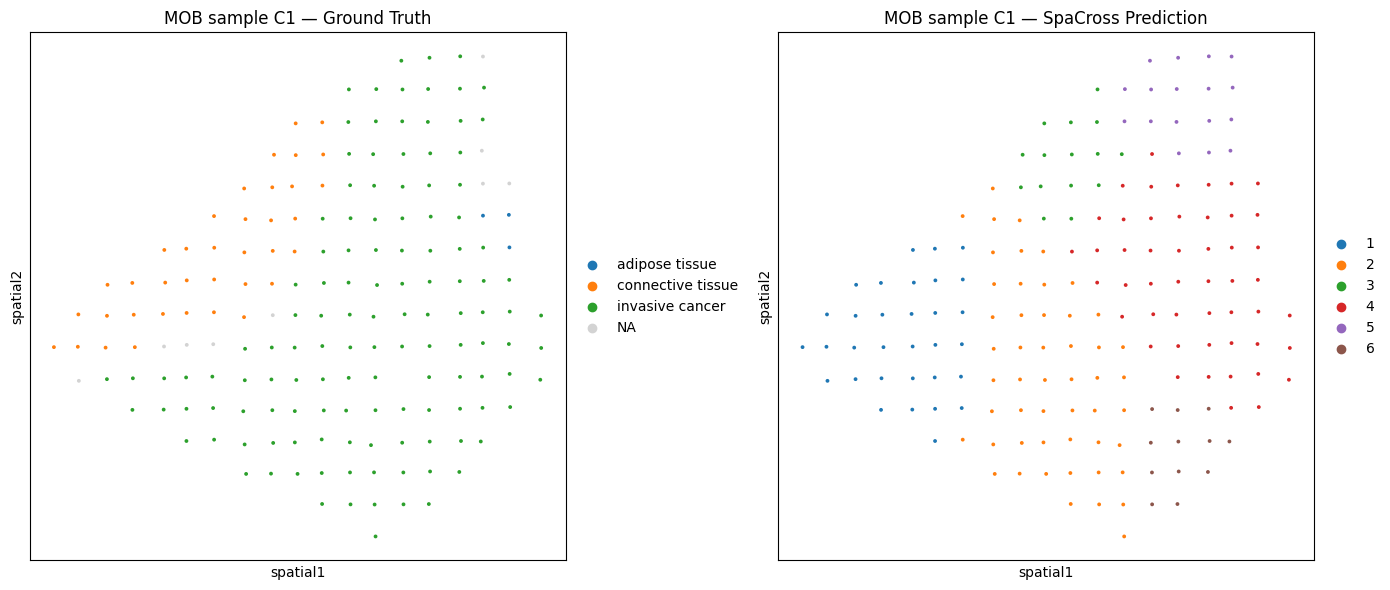

In [ ]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path

DATA_ROOT = Path("/groups/qiwei/mocha/QuickSRT/BC_HER2+_ST/data")
OUTPUT_DIR = Path("/home/dal875013/work/projects/mocha/results/Spacross/bc_her2_spacross")

# "A1", "B1", "C1", "D1", "E1", "F1", "G2", "H1"
SAMPLE_ID = "C1"

predictions = pd.read_parquet(OUTPUT_DIR / "predictions.parquet")

# 统一成字符串再筛，避免 parquet 里 sample 列是 int/string 不一致
predictions["sample"] = predictions["sample"].astype(str)
pred_slice = predictions[predictions["sample"] == str(SAMPLE_ID)].copy()

if pred_slice.empty:
    raise ValueError(f"No predictions found for sample {SAMPLE_ID}")

pred_slice = pred_slice.set_index("spot_id")

adata = sc.read_h5ad(DATA_ROOT / f"SCE_{SAMPLE_ID}.h5ad")
adata.var_names_make_unique()

# 兼容你的 h5ad 坐标存储
if "spatial" not in adata.obsm:
    if "S" in adata.obsm:
        adata.obsm["spatial"] = np.asarray(adata.obsm["S"])
    else:
        raise KeyError(f"No spatial coordinates found. obsm keys = {list(adata.obsm.keys())}")

# 对齐 spot 顺序
adata.obs["true_label"] = pred_slice["true_label"].reindex(adata.obs_names).values
adata.obs["pred_label"] = pred_slice["pred_label"].reindex(adata.obs_names).values

print(f"SAMPLE_ID = {SAMPLE_ID}")
print(f"n spots in adata      : {adata.n_obs}")
print(f"n predictions matched : {pred_slice.index.isin(adata.obs_names).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc.pl.embedding(
    adata,
    basis="spatial",
    color="true_label",
    ax=axes[0],
    show=False,
    title=f"MOB sample {SAMPLE_ID} — Ground Truth",
    s=100,
)

sc.pl.embedding(
    adata,
    basis="spatial",
    color="pred_label",
    ax=axes[1],
    show=False,
    title=f"MOB sample {SAMPLE_ID} — SpaCross Prediction",
    s=100,
)

axes[0].invert_yaxis()
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

# Running results summary

In [ ]:
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path("/home/dal875013/work/projects/mocha/results/Spacross/bc_her2_spacross")

perf_path = OUTPUT_DIR / "performance.parquet"

if not perf_path.exists():
    raise FileNotFoundError(f"Cannot find {perf_path}")

performance = pd.read_parquet(perf_path)

# 按 sample 排序，输出全部结果
performance = performance.sort_values(["sample", "run_seed"]).reset_index(drop=True)

display_cols = [
    "sample", "run_seed", "ARI", "NMI", "ACC", "DIS",
    "num_clusters", "num_spots", "num_labeled_spots",
    "running_time_sec", "clust_method", "gpu_model"
]

display_cols = [c for c in display_cols if c in performance.columns]

print("===== All SpaCross results =====")
display(performance[display_cols])

print("\n===== Summary =====")
summary = performance[["ARI", "NMI", "ACC", "DIS", "running_time_sec"]].describe()
display(summary)

print("\n===== Mean metrics =====")
print(f"Mean ARI: {performance['ARI'].mean():.4f}")
print(f"Mean NMI: {performance['NMI'].mean():.4f}")
print(f"Mean ACC: {performance['ACC'].mean():.4f}")
print(f"Mean DIS: {performance['DIS'].mean():.4f}")

print("\n===== Best / worst ARI =====")
best = performance.loc[performance["ARI"].idxmax()]
worst = performance.loc[performance["ARI"].idxmin()]

print(f"Best ARI : {best['sample']}  ARI={best['ARI']:.4f}")
print(f"Worst ARI: {worst['sample']}  ARI={worst['ARI']:.4f}")

===== All SpaCross results =====


,sample,run_seed,ARI,NMI,ACC,DIS,num_clusters,num_spots,num_labeled_spots,running_time_sec,clust_method,gpu_model
0,A1,0,0.072540,0.216116,0.247274,0.080482,6,346,341,6.19,mclust,NVIDIA A30
1,B1,0,0.247608,0.400554,0.405028,0.104286,6,295,269,3.95,mclust,NVIDIA A30
2,C1,0,0.086421,0.202308,0.237488,0.134727,6,176,167,3.74,mclust,NVIDIA A30
3,D1,0,0.126077,0.174416,0.184858,0.101841,6,306,255,3.93,mclust,NVIDIA A30
4,E1,0,0.139043,0.236990,0.261421,0.075322,6,587,534,4.60,mclust,NVIDIA A30
5,F1,0,0.041265,0.130077,0.173686,0.079636,6,691,659,4.66,mclust,NVIDIA A30
6,G2,0,0.288235,0.317624,0.318550,0.081892,6,467,402,4.25,mclust,NVIDIA A30
7,H1,0,0.203289,0.358023,0.358051,0.083128,6,613,530,5.15,mclust,NVIDIA A30



===== Summary =====


,ARI,NMI,ACC,DIS,running_time_sec
count,8.000000,8.000000,8.000000,8.000000,8.000000
mean,0.150560,0.254514,0.273294,0.092664,4.558750
std,0.087857,0.094440,0.081441,0.020051,0.806588
min,0.041265,0.130077,0.173686,0.075322,3.740000
25%,0.082951,0.195335,0.224331,0.080271,3.945000
50%,0.132560,0.226553,0.254348,0.082510,4.425000
75%,0.214369,0.327724,0.328425,0.102453,4.782500
max,0.288235,0.400554,0.405028,0.134727,6.190000



===== Mean metrics =====
Mean ARI: 0.1506
Mean NMI: 0.2545
Mean ACC: 0.2733
Mean DIS: 0.0927

===== Best / worst ARI =====
Best ARI : G2  ARI=0.2882
Worst ARI: F1  ARI=0.0413


# actual layer in ground truth checking

In [1]:
import scanpy as sc
import pandas as pd
from pathlib import Path

DATA_ROOT = Path("/groups/qiwei/mocha/QuickSRT/BC_HER2+_ST/data")

ALL_BC_HER2_SAMPLES = [
    "A1",
    "B1",
    "C1",
    "D1",
    "E1",
    "F1",
    "G2",
    "H1",
]

results = []

for sample_id in ALL_BC_HER2_SAMPLES:
    path = DATA_ROOT / f"SCE_{sample_id}.h5ad"

    if not path.exists():
        print(f"[MISSING] {sample_id}: {path}")
        continue

    adata = sc.read_h5ad(path)

    if "z" not in adata.obs:
        print(f"[NO LABEL] {sample_id}; obs columns = {list(adata.obs.columns)}")
        continue

    labels_all = adata.obs["z"]

    # remove NaN labels
    labels = labels_all.dropna()

    unique_labels = sorted(labels.unique())
    n_classes = len(unique_labels)

    results.append({
        "sample": sample_id,
        "n_classes": n_classes,
        "labels": unique_labels,
        "n_spots": adata.n_obs,
        "n_labeled": len(labels),
        "n_NA": int(labels_all.isna().sum()),
    })

df = pd.DataFrame(results).sort_values("n_classes")

print("===== BC_HER2+_ST: Per-sample class counts =====")
display(df)

print("\n===== Summary =====")
print(df["n_classes"].value_counts().sort_index())

print("\n===== Samples with only 1 class =====")
print(df[df["n_classes"] == 1]["sample"].tolist())

print("\n===== Suggested dictionary: sample -> n_classes =====")
cluster_dict = dict(zip(df["sample"], df["n_classes"]))
print(cluster_dict)

===== BC_HER2+_ST: Per-sample class counts =====


,sample,n_classes,labels,n_spots,n_labeled,n_NA
3,D1,3,"[connective tissue, immune infiltrate, invasiv...",306,255,51
2,C1,3,"[adipose tissue, connective tissue, invasive c...",176,167,9
5,F1,3,"[connective tissue, immune infiltrate, invasiv...",691,659,32
4,E1,3,"[connective tissue, immune infiltrate, invasiv...",587,534,53
1,B1,4,"[adipose tissue, breast glands, connective tis...",295,269,26
0,A1,5,"[adipose tissue, cancer in situ, connective ti...",346,341,5
6,G2,6,"[adipose tissue, breast glands, cancer in situ...",467,402,65
7,H1,6,"[adipose tissue, breast glands, cancer in situ...",613,530,83



===== Summary =====
n_classes
3    4
4    1
5    1
6    2
Name: count, dtype: int64

===== Samples with only 1 class =====
[]

===== Suggested dictionary: sample -> n_classes =====
{'D1': 3, 'C1': 3, 'F1': 3, 'E1': 3, 'B1': 4, 'A1': 5, 'G2': 6, 'H1': 6}
